In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import warnings

In [3]:
from src import test, train

In [4]:
warnings.filterwarnings("ignore")

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(-64830.242),
 'loss_batch_mean': np.float32(-506.48627),
 'log_w': np.float32(56726.45),
 'log_w_batch_mean': np.float32(443.17538)}

In [7]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

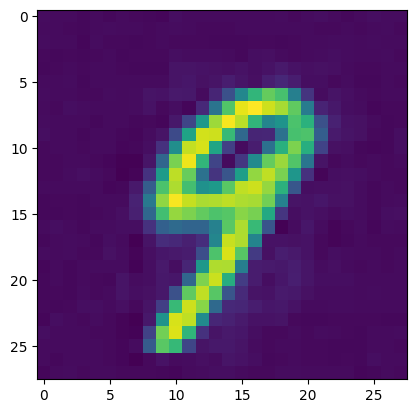

In [8]:
plt.imshow(recons[0].squeeze())

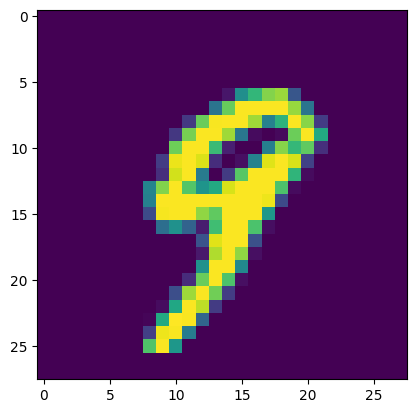

In [9]:
plt.imshow(data[0].squeeze())

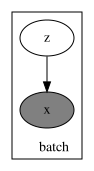

In [10]:
objects['monad'].render_model()

In [11]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [12]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [13]:
portion_zeros(zs)

Array(0.91962105, dtype=float32)

In [14]:
r2(xs, xs_hat)

Array(0.90194225, dtype=float32)

In [15]:
xs.shape

(9984, 1, 28, 28)

In [16]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [17]:
metrics

{'loss': np.float32(-28014.285),
 'loss_batch_mean': np.float32(-218.8616),
 'log_w': np.float32(24512.5),
 'log_w_batch_mean': np.float32(191.5039)}

In [18]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

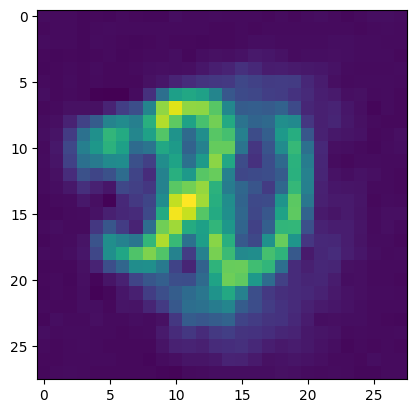

In [19]:
plt.imshow(recons[0].squeeze())

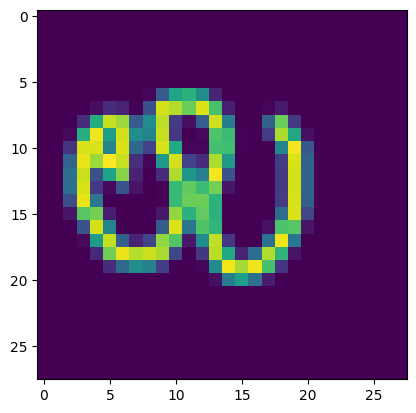

In [20]:
plt.imshow(data[0].squeeze())

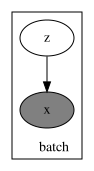

In [21]:
objects['monad'].render_model()

In [22]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [23]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [24]:
portion_zeros(zs)

Array(0.93021846, dtype=float32)

In [25]:
r2(xs, xs_hat)

Array(0.6232084, dtype=float32)

In [26]:
xs.shape

(13056, 1, 28, 28)

In [27]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], ckpt_path="logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                      t_total=1_000)

15it [2:03:56, 495.75s/it]


In [28]:
metrics

{'du_norm': Array([44.65944  , 21.505766 , 16.516987 , 14.964249 , 14.612232 ,
        14.559402 , 14.569586 , 14.621296 , 14.684068 , 14.72442  ,
        14.738588 , 14.741508 , 14.744587 , 14.750491 , 14.7579565,
        14.765581 , 14.772432 , 14.778025 , 14.782221 , 14.7851925,
        14.787159 , 14.788364 , 14.789033 , 14.789375 , 14.789545 ,
        14.78967  , 14.789817 , 14.790072 , 14.790436 , 14.790885 ,
        14.7913885, 14.791905 , 14.7923975, 14.7928295, 14.793207 ,
        14.793531 , 14.793807 , 14.794064 , 14.794279 , 14.794477 ,
        14.7946615, 14.794818 , 14.794937 , 14.7950325, 14.795098 ,
        14.79513  , 14.795126 , 14.795119 , 14.7951   , 14.795082 ,
        14.795065 , 14.795041 , 14.795042 , 14.795031 , 14.795034 ,
        14.795035 , 14.795036 , 14.795036 , 14.795043 , 14.795042 ,
        14.795056 , 14.79506  , 14.79507  , 14.795073 , 14.795079 ,
        14.795079 , 14.795088 , 14.795098 , 14.795109 , 14.795107 ,
        14.79512  , 14.795121 , 14.79

In [29]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=emnist", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [30]:
metrics

{'loss': np.float32(142511.17),
 'loss_batch_mean': np.float32(1113.3685),
 'log_w': np.float32(-124697.26),
 'log_w_batch_mean': np.float32(-974.1973)}

In [31]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

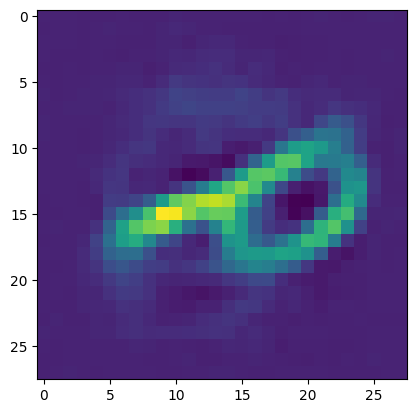

In [32]:
plt.imshow(recons[0].squeeze())

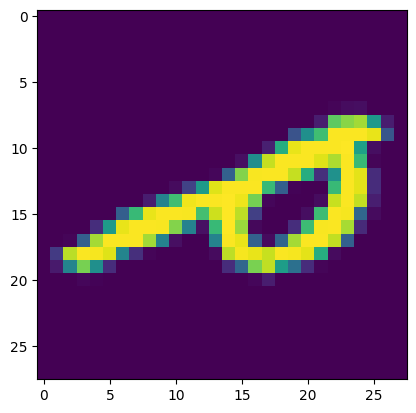

In [33]:
plt.imshow(data[0].squeeze())

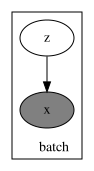

In [34]:
objects['monad'].render_model()

In [35]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [36]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [37]:
portion_zeros(zs)

Array(0.914987, dtype=float32)

In [38]:
r2(xs, xs_hat)

Array(0.5284223, dtype=float32)

In [39]:
xs.shape

(18688, 1, 28, 28)

In [40]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], ckpt_path="logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                      t_total=1_000)

88it [12:56:17, 529.29s/it]


In [41]:
metrics

{'du_norm': Array([44.847084, 22.402029, 18.578798, 18.00074 , 18.169062, 18.341492,
        18.42964 , 18.473097, 18.497978, 18.512175, 18.519505, 18.523403,
        18.525965, 18.52803 , 18.529772, 18.53118 , 18.532223, 18.532944,
        18.53341 , 18.533724, 18.533936, 18.53409 , 18.534208, 18.534279,
        18.534323, 18.534334, 18.534338, 18.534332, 18.534332, 18.534328,
        18.534334, 18.534348, 18.534365, 18.534376, 18.534388, 18.534399,
        18.534409, 18.534418, 18.534424, 18.534435, 18.53444 , 18.534443,
        18.534441, 18.534441, 18.534447, 18.534449, 18.534445, 18.534447,
        18.534443, 18.534443, 18.534443, 18.534443, 18.534443, 18.534445,
        18.534449, 18.534445, 18.534441, 18.534447, 18.534449, 18.534443,
        18.534441, 18.534441, 18.534443, 18.534449, 18.534441, 18.53444 ,
        18.53444 , 18.534441, 18.534441, 18.534449, 18.534443, 18.534443,
        18.534447, 18.534445, 18.534449, 18.534447, 18.534443, 18.534447,
        18.534441, 18.53444